# Early Warning System: Who Is Struggling Next Month?

## 1. Problem Framing

**Business Question:** Which girls are likely to be struggling next month versus progressing, so case managers can prioritize support early?

**Primary lens (predictive):** predict `y_next_struggling` for resident-month observations.

**Primary target definition (`y_next_struggling`):** `1` when next month shows signs of struggle (elevated incident and/or high concern burden and/or notable health decline), otherwise `0`.

**Sensitivity targets (reported later):**
- `y_next_elevated_incident` for incident-focused risk,
- high-only (`severity == "High"`) for strict safety comparison.

**Who uses this:** safehouse supervisors and social workers for monthly triage planning.

**Why it matters:** this aligns directly to case-management workflow (who is struggling now), not only rare severe-incident prediction.


## Predictive and Explanatory Modeling Map

- **Predictive modeling (what next):** model comparison and selection in `## 3. Modeling & Feature Selection`, with operating-threshold guidance in `## 4. Evaluation & Interpretation`.
- **Explanatory modeling (what is associated):** interpretable logistic model with odds-ratio style readout in `## 5. Causal and Relationship Analysis`.
- **Operationalization:** risk tiers and action playbook in `## 6. Deployment Notes`.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ModuleNotFoundError:
    HAS_SEABORN = False

try:
    from IPython.display import display
    from IPython import get_ipython
except ModuleNotFoundError:
    def display(x):
        print(x)
    def get_ipython():
        return None

# Ensure charts render inside notebook cells (not external windows).
ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
)

if HAS_SEABORN:
    sns.set_theme(style="whitegrid")
else:
    plt.style.use("ggplot")

pd.set_option("display.max_columns", 200)


In [2]:
# Robust data path whether notebook runs from project root, ml-pipelines/, or another cwd
search_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
DATA_DIR = None
for root in search_roots:
    candidate = root / "data"
    if candidate.exists():
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    raise FileNotFoundError("Could not locate data directory.")

TABLES = {
    "residents": "residents.csv",
    "health": "health_wellbeing_records.csv",
    "process": "process_recordings.csv",
    "education": "education_records.csv",
    "visits": "home_visitations.csv",
    "plans": "intervention_plans.csv",
    "incidents": "incident_reports.csv",
}

residents = pd.read_csv(DATA_DIR / TABLES["residents"])
health = pd.read_csv(DATA_DIR / TABLES["health"])
process = pd.read_csv(DATA_DIR / TABLES["process"])
education = pd.read_csv(DATA_DIR / TABLES["education"])
visits = pd.read_csv(DATA_DIR / TABLES["visits"])
plans = pd.read_csv(DATA_DIR / TABLES["plans"])
incidents = pd.read_csv(DATA_DIR / TABLES["incidents"])

for df, col in [
    (health, "record_date"),
    (process, "session_date"),
    (education, "record_date"),
    (visits, "visit_date"),
    (plans, "created_at"),
    (plans, "updated_at"),
    (incidents, "incident_date"),
]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")


## 2. Data Acquisition, Preparation & Exploration

We build a resident-month panel using only information available by end of month `m`, then align outcomes to month `m+1`.


In [3]:
def month_start(series):
    return pd.to_datetime(series, errors="coerce").dt.to_period("M").dt.to_timestamp()

# Base resident-month frame across observable timeline
months = pd.concat([
    month_start(health["record_date"]),
    month_start(process["session_date"]),
    month_start(education["record_date"]),
    month_start(visits["visit_date"]),
    month_start(plans["created_at"]),
    month_start(incidents["incident_date"]),
], axis=0).dropna()

all_months = pd.date_range(months.min(), months.max(), freq="MS")
panel = pd.MultiIndex.from_product(
    [residents["resident_id"].dropna().unique(), all_months],
    names=["resident_id", "month_m"],
).to_frame(index=False)

panel["month_index"] = (panel["month_m"].dt.year * 12 + panel["month_m"].dt.month).astype(int)
panel.head()


,resident_id,month_m,month_index
0,1,2023-01-01,24277
1,1,2023-02-01,24278
2,1,2023-03-01,24279
3,1,2023-04-01,24280
4,1,2023-05-01,24281


In [4]:
# Health features + month-over-month deltas
health_f = health.copy()
health_f["month_m"] = month_start(health_f["record_date"])

# Handle small schema differences across datasets.
sleep_col = "sleep_score" if "sleep_score" in health_f.columns else "sleep_quality_score"
energy_col = "energy_score" if "energy_score" in health_f.columns else "energy_level_score"

health_monthly = (
    health_f.groupby(["resident_id", "month_m"], as_index=False)
    .agg(
        nutrition_score_m=("nutrition_score", "mean"),
        sleep_score_m=(sleep_col, "mean"),
        energy_score_m=(energy_col, "mean"),
        general_health_score_m=("general_health_score", "mean"),
        bmi_m=("bmi", "mean"),
        psych_checkup_m=("psychological_checkup_done", "max"),
        med_checkup_m=("medical_checkup_done", "max"),
        dental_checkup_m=("dental_checkup_done", "max"),
    )
    .sort_values(["resident_id", "month_m"])
)

for c in ["nutrition_score_m", "sleep_score_m", "energy_score_m", "general_health_score_m"]:
    health_monthly[f"delta_{c}"] = health_monthly.groupby("resident_id")[c].diff()

panel = panel.merge(health_monthly, on=["resident_id", "month_m"], how="left")


In [5]:
# Process recording features (session intensity + concern signals)
proc_f = process.copy()
proc_f["month_m"] = month_start(proc_f["session_date"])
risk_states = {"Anxious", "Sad", "Angry", "Withdrawn", "Distressed"}
proc_f["start_risk_state"] = proc_f["emotional_state_observed"].isin(risk_states).astype(int)
proc_f["end_risk_state"] = proc_f["emotional_state_end"].isin(risk_states).astype(int)

proc_monthly = (
    proc_f.groupby(["resident_id", "month_m"], as_index=False)
    .agg(
        sessions_count_m=("recording_id", "count"),
        avg_session_duration_m=("session_duration_minutes", "mean"),
        concerns_rate_m=("concerns_flagged", "mean"),
        progress_rate_m=("progress_noted", "mean"),
        referral_rate_m=("referral_made", "mean"),
        start_risk_state_rate_m=("start_risk_state", "mean"),
        end_risk_state_rate_m=("end_risk_state", "mean"),
    )
)
panel = panel.merge(proc_monthly, on=["resident_id", "month_m"], how="left")


In [6]:
# Education features (schema-flexible)
edu_f = education.copy()
edu_f["month_m"] = month_start(edu_f["record_date"])

if "attendance_status" in edu_f.columns:
    edu_f["is_absent"] = (edu_f["attendance_status"] == "Absent").astype(int)
    edu_f["is_late"] = (edu_f["attendance_status"] == "Late").astype(int)
else:
    # Fallback for schemas that use enrollment_status instead of attendance_status.
    edu_f["is_absent"] = 0
    edu_f["is_late"] = 0

if "gpa_like_score" not in edu_f.columns:
    edu_f["gpa_like_score"] = np.nan

edu_monthly = (
    edu_f.groupby(["resident_id", "month_m"], as_index=False)
    .agg(
        attendance_rate_m=("attendance_rate", "mean"),
        progress_percent_m=("progress_percent", "mean"),
        gpa_like_score_m=("gpa_like_score", "mean"),
        absent_rate_m=("is_absent", "mean"),
        late_rate_m=("is_late", "mean"),
    )
)
panel = panel.merge(edu_monthly, on=["resident_id", "month_m"], how="left")


In [7]:
# Home visitation features
vis_f = visits.copy()
vis_f["month_m"] = month_start(vis_f["visit_date"])
vis_f["unfavorable_visit"] = vis_f["visit_outcome"].isin(["Needs Improvement", "Unfavorable"]).astype(int)

vis_monthly = (
    vis_f.groupby(["resident_id", "month_m"], as_index=False)
    .agg(
        visit_count_m=("visitation_id", "count"),
        safety_concerns_count_m=("safety_concerns_noted", "sum"),
        follow_up_needed_rate_m=("follow_up_needed", "mean"),
        unfavorable_visit_rate_m=("unfavorable_visit", "mean"),
    )
)
panel = panel.merge(vis_monthly, on=["resident_id", "month_m"], how="left")


In [8]:
# Intervention activity features (created/updated touches)
plan_events = []
for event_col, event_name in [("created_at", "intervention_created_m"), ("updated_at", "intervention_updated_m")]:
    tmp = plans[["resident_id", event_col]].copy()
    tmp["month_m"] = month_start(tmp[event_col])
    tmp = tmp.dropna(subset=["month_m"])
    tmp[event_name] = 1
    plan_events.append(tmp[["resident_id", "month_m", event_name]])

plan_created = plan_events[0].groupby(["resident_id", "month_m"], as_index=False)["intervention_created_m"].sum()
plan_updated = plan_events[1].groupby(["resident_id", "month_m"], as_index=False)["intervention_updated_m"].sum()
plan_monthly = plan_created.merge(plan_updated, on=["resident_id", "month_m"], how="outer").fillna(0)
plan_monthly["intervention_touches_m"] = plan_monthly["intervention_created_m"] + plan_monthly["intervention_updated_m"]

panel = panel.merge(plan_monthly, on=["resident_id", "month_m"], how="left")


In [9]:
# Incident features at month m (allowed) and target in month m+1
inc_f = incidents.copy()
inc_f["month_m"] = month_start(inc_f["incident_date"])
inc_f["is_high"] = (inc_f["severity"] == "High").astype(int)
inc_f["is_elevated"] = inc_f["severity"].isin(["Medium", "High"]).astype(int)

inc_monthly = (
    inc_f.groupby(["resident_id", "month_m"], as_index=False)
    .agg(
        incident_count_m=("incident_id", "count"),
        high_incident_count_m=("is_high", "sum"),
        elevated_incident_count_m=("is_elevated", "sum"),
    )
)
inc_monthly["incident_any_m"] = (inc_monthly["incident_count_m"] > 0).astype(int)
inc_monthly["high_incident_any_m"] = (inc_monthly["high_incident_count_m"] > 0).astype(int)
inc_monthly["elevated_incident_any_m"] = (inc_monthly["elevated_incident_count_m"] > 0).astype(int)

panel = panel.merge(inc_monthly, on=["resident_id", "month_m"], how="left")

# Primary target: medium+high next month.
target_map = inc_monthly[["resident_id", "month_m", "elevated_incident_any_m", "high_incident_any_m"]].rename(
    columns={
        "month_m": "target_month",
        "elevated_incident_any_m": "y_next_elevated_incident",
        "high_incident_any_m": "y_next_high_incident_sensitivity",
    }
)
panel["target_month"] = panel["month_m"] + pd.offsets.MonthBegin(1)
panel = panel.merge(target_map, on=["resident_id", "target_month"], how="left")


In [10]:
# Resident baseline context (static descriptors)
resident_cols = [
    "resident_id", "safehouse_id", "case_category", "initial_risk_level", "current_risk_level",
    "referral_source", "has_special_needs", "is_pwd", "sub_cat_trafficked", "sub_cat_sexual_abuse",
]
resident_base = residents[resident_cols].copy()
panel = panel.merge(resident_base, on="resident_id", how="left")

# Keep only months where month m+1 label is fully observable in incident data (avoid right-censoring).
max_incident_month = month_start(incidents["incident_date"]).max()
model_df = panel[panel["target_month"] <= max_incident_month].copy()

# Primary and sensitivity targets
model_df["y_next_elevated_incident"] = model_df["y_next_elevated_incident"].fillna(0).astype(int)
model_df["y_next_high_incident_sensitivity"] = model_df["y_next_high_incident_sensitivity"].fillna(0).astype(int)

# Fill count/rate style monthly features with 0 when absent events occurred
fill_zero_cols = [c for c in model_df.columns if c.endswith("_m") or c.startswith("delta_")]
for col in fill_zero_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)

# Add progression/struggle framing target for case-management decisions.
model_df = model_df.sort_values(["resident_id", "month_m"]).copy()
next_health = model_df.groupby("resident_id")["general_health_score_m"].shift(-1)
next_concerns = model_df.groupby("resident_id")["concerns_rate_m"].shift(-1)
next_progress = model_df.groupby("resident_id")["progress_rate_m"].shift(-1)
next_elevated = model_df.groupby("resident_id")["y_next_elevated_incident"].shift(0)

health_drop = ((next_health - model_df["general_health_score_m"]) <= -0.35).fillna(False)
high_concern_next = (next_concerns >= 0.50).fillna(False)
low_progress_next = (next_progress <= 0.20).fillna(False)

model_df["y_next_struggling"] = (
    (next_elevated == 1) |
    high_concern_next |
    health_drop |
    (low_progress_next & (next_concerns >= 0.30).fillna(False))
).astype(int)

model_df["y_next_progressing"] = (
    ((next_elevated == 0) | next_elevated.isna()) &
    (next_concerns <= 0.20).fillna(False) &
    (next_progress >= 0.70).fillna(False) &
    ((next_health - model_df["general_health_score_m"]) >= 0.10).fillna(False)
).astype(int)

model_df[["resident_id", "month_m", "target_month", "y_next_struggling", "y_next_elevated_incident", "y_next_high_incident_sensitivity"]].head()


,resident_id,month_m,target_month,y_next_struggling,y_next_elevated_incident,y_next_high_incident_sensitivity
0,1,2023-01-01,2023-02-01,0,0,0
1,1,2023-02-01,2023-03-01,0,0,0
2,1,2023-03-01,2023-04-01,0,0,0
3,1,2023-04-01,2023-05-01,0,0,0
4,1,2023-05-01,2023-06-01,0,0,0


### Feature glossary

- `*_m`: value observed or aggregated in current month `m`.
- `delta_*`: month-over-month change from `m-1` to `m` for resident health signals.
- `sessions_count_m`, `concerns_rate_m`, `referral_rate_m`: monthly counseling volume and concern/referral intensity.
- `visit_count_m`, `safety_concerns_count_m`, `follow_up_needed_rate_m`: monthly visitation workload and risk cues.
- `intervention_created_m`, `intervention_updated_m`, `intervention_touches_m`: intervention-plan activity logged in month `m`.
- `incident_*_m`: incident activity in month `m` (allowed as historical/current risk context).
- `y_next_struggling`: primary target for case-management triage (next-month struggle flag).
- `y_next_progressing`: stricter next-month progress flag (used for interpretation, not model target).
- `y_next_elevated_incident`: medium/high-severity next-month incident flag (sensitivity target).
- `y_next_high_incident_sensitivity`: high-severity next-month incident flag (strict sensitivity target).


In [11]:
# Quick exploratory readout
base_rate_struggle = model_df["y_next_struggling"].mean()
base_rate_progress = model_df["y_next_progressing"].mean()
base_rate_elev = model_df["y_next_elevated_incident"].mean()
base_rate_high = model_df["y_next_high_incident_sensitivity"].mean()
print(f"Resident-month rows: {len(model_df):,}")
print(f"Residents: {model_df['resident_id'].nunique():,}")
print(f"Months: {model_df['month_m'].nunique():,}")
print(f"Primary base rate (next-month struggling): {base_rate_struggle:.3f}")
print(f"Progress signal rate (next-month progressing): {base_rate_progress:.3f}")
print(f"Sensitivity base rate (next-month elevated incident, Medium+High): {base_rate_elev:.3f}")
print(f"Strict safety base rate (next-month high-only): {base_rate_high:.3f}")


Resident-month rows: 2,340
Residents: 60
Months: 39
Primary base rate (next-month struggling): 0.156
Progress signal rate (next-month progressing): 0.028
Sensitivity base rate (next-month elevated incident, Medium+High): 0.029
Strict safety base rate (next-month high-only): 0.010


### Exploration visuals — correlations and label separation

These charts use **month `m` predictors** (and static resident fields) against the **primary label** `y_next_struggling` (next-month struggle). They help confirm the panel has sensible signal before we train models.

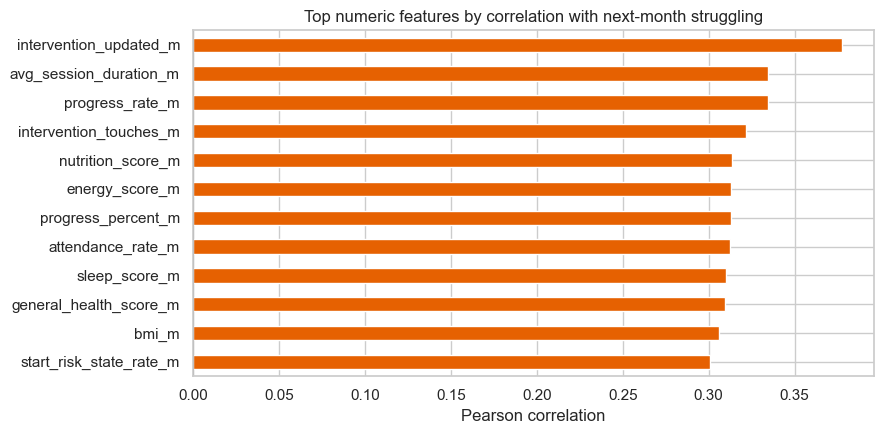

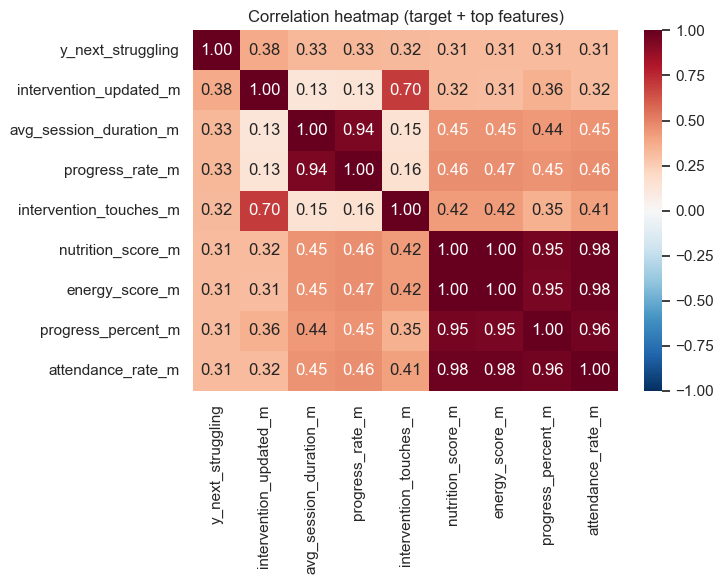

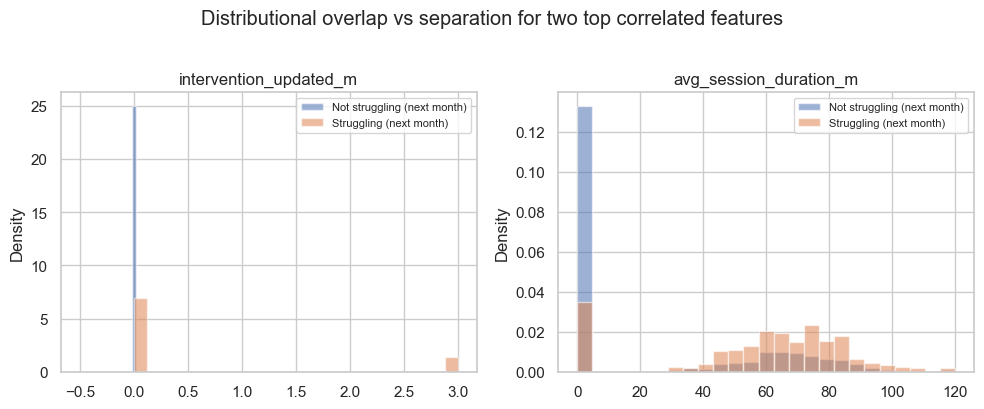

In [12]:
# Correlations with the primary target + quick distributional separation (numeric features only)
eda_target = "y_next_struggling"
exclude_corr = {
    eda_target,
    "y_next_progressing",
    "y_next_elevated_incident",
    "y_next_high_incident_sensitivity",
    "target_month",
    "month_m",
    "resident_id",
    "month_index",
}
num_candidates = [
    c
    for c in model_df.select_dtypes(include=[np.number]).columns
    if c not in exclude_corr
]
if len(num_candidates) < 3:
    print("Skipping correlation visuals: not enough numeric feature columns.")
else:
    corr_block = model_df[num_candidates + [eda_target]].corr(numeric_only=True)
    corr_y = corr_block[eda_target].drop(eda_target, errors="ignore").replace([np.inf, -np.inf], np.nan).dropna()
    top_feats = corr_y.abs().sort_values(ascending=False).head(12).index.tolist()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    plot_s = corr_y.loc[top_feats].sort_values()
    colors = ["#2c7fb8" if v < 0 else "#e66101" for v in plot_s.values]
    plot_s.plot(kind="barh", ax=ax, color=colors)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_title("Top numeric features by correlation with next-month struggling")
    ax.set_xlabel("Pearson correlation")
    plt.tight_layout()
    plt.show()

    heat_cols = [eda_target] + top_feats[:8]
    heat = model_df[heat_cols].corr()
    fig2, ax2 = plt.subplots(figsize=(7.5, 6))
    if HAS_SEABORN:
        sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax2)
    else:
        im = ax2.imshow(heat, cmap="RdBu_r", vmin=-1, vmax=1)
        ax2.set_xticks(range(len(heat.columns)))
        ax2.set_yticks(range(len(heat.columns)))
        ax2.set_xticklabels(heat.columns, rotation=45, ha="right")
        ax2.set_yticklabels(heat.columns)
        plt.colorbar(im, ax=ax2, fraction=0.046)
    ax2.set_title("Correlation heatmap (target + top features)")
    plt.tight_layout()
    plt.show()

    sep_a, sep_b = top_feats[0], top_feats[min(1, len(top_feats) - 1)]
    fig3, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax_h, col in zip(axes, [sep_a, sep_b]):
        s0 = model_df.loc[model_df[eda_target] == 0, col].dropna()
        s1 = model_df.loc[model_df[eda_target] == 1, col].dropna()
        ax_h.hist(s0, bins=25, alpha=0.55, density=True, label="Not struggling (next month)")
        ax_h.hist(s1, bins=25, alpha=0.55, density=True, label="Struggling (next month)")
        ax_h.set_title(col)
        ax_h.set_ylabel("Density")
        ax_h.legend(fontsize=8)
    plt.suptitle("Distributional overlap vs separation for two top correlated features", y=1.02)
    plt.tight_layout()
    plt.show()

### How to read the exploration charts

- **Correlation bar chart:** Each bar is a simple linear association between a numeric month-`m` field and next-month struggling (`1` / `0`). Larger absolute values mean stronger association in this snapshot; sign shows direction. This is **not** causation and not the same as model feature importance.
- **Heatmap:** Shows how the target lines up with a small set of the strongest numeric correlates and how those features relate to each other. Red flags **multicollinearity** (features moving together), which is expected for related case-work signals.
- **Overlapping histograms:** If the orange (struggling) and blue (not struggling) shapes look similar, the feature is a weak separator by itself; if the peaks shift apart, the feature helps tell the groups apart. Models combine many fields, so a messy single feature is normal.


## 3. Modeling & Feature Selection

We use a chronological split and compare multiple classifiers for prediction. We also retain an interpretable logistic model for explanatory readout.


In [13]:
# Chronological train/validation/test split
# Preference: 60/20/20 by months. Fallback: relax for class coverage when needed.
target_col = "y_next_struggling"
sensitivity_col = "y_next_high_incident_sensitivity"

month_values = sorted(model_df["month_m"].unique())
n_months = len(month_values)

if n_months < 12:
    raise ValueError("Not enough monthly history for stable chronological train/validation/test split.")

# Preferred 60/20/20 split by month count
preferred_train_end = max(1, int(round(n_months * 0.60)))
preferred_val_end = max(preferred_train_end + 1, int(round(n_months * 0.80)))
preferred_val_end = min(preferred_val_end, n_months - 1)

MIN_TRAIN_MONTHS = 12
MIN_VAL_MONTHS = 4
MIN_TEST_MONTHS = 4
MIN_VAL_POS = 3
MIN_TEST_POS = 3

monthly_pos = (
    model_df.groupby("month_m", as_index=False)[target_col]
    .sum()
    .rename(columns={target_col: "pos_count"})
)
pos_by_month = dict(zip(monthly_pos["month_m"], monthly_pos["pos_count"]))

def split_info(v_cut, t_cut):
    train_m = month_values[:v_cut]
    val_m = month_values[v_cut:t_cut]
    test_m = month_values[t_cut:]
    val_pos = sum(pos_by_month.get(m, 0) for m in val_m)
    test_pos = sum(pos_by_month.get(m, 0) for m in test_m)
    return train_m, val_m, test_m, val_pos, test_pos

# 1) Try preferred split first
train_months, val_months, test_months, val_pos, test_pos = split_info(preferred_train_end, preferred_val_end)
used_fallback = False

preferred_ok = (
    len(train_months) >= MIN_TRAIN_MONTHS
    and len(val_months) >= MIN_VAL_MONTHS
    and len(test_months) >= MIN_TEST_MONTHS
    and val_pos >= MIN_VAL_POS
    and test_pos >= MIN_TEST_POS
)

# 2) Fallback: search nearby chronological splits if class coverage is weak
if not preferred_ok:
    used_fallback = True
    candidates = []
    for t_cut in range(1, n_months):
        for v_cut in range(1, t_cut):
            tr_m, va_m, te_m, va_pos, te_pos = split_info(v_cut, t_cut)
            if len(tr_m) < MIN_TRAIN_MONTHS or len(va_m) < MIN_VAL_MONTHS or len(te_m) < MIN_TEST_MONTHS:
                continue
            # Minimize distance from 60/20/20 while prioritizing positive coverage
            dist = abs(v_cut - preferred_train_end) + abs(t_cut - preferred_val_end)
            coverage_score = int(va_pos >= MIN_VAL_POS) + int(te_pos >= MIN_TEST_POS)
            balance_score = -abs(len(va_m) - len(te_m))
            candidates.append((coverage_score, -dist, balance_score, va_pos + te_pos, v_cut, t_cut))

    if not candidates:
        raise ValueError("No feasible chronological split found with minimum month constraints.")

    best = sorted(candidates, reverse=True)[0]
    _, _, _, _, best_v, best_t = best
    train_months, val_months, test_months, val_pos, test_pos = split_info(best_v, best_t)

train_df = model_df[model_df["month_m"].isin(train_months)].copy()
val_df = model_df[model_df["month_m"].isin(val_months)].copy()
test_df = model_df[model_df["month_m"].isin(test_months)].copy()

if len(val_df) == 0 or len(test_df) == 0:
    raise ValueError("Validation or test split is empty. Check date coverage and split logic.")

print("Split strategy:", "fallback (coverage-adjusted)" if used_fallback else "preferred 60/20/20")
print("Split months:")
print(f"- Train: {train_df['month_m'].min().date()} to {train_df['month_m'].max().date()} ({train_df['month_m'].nunique()} months)")
print(f"- Val:   {val_df['month_m'].min().date()} to {val_df['month_m'].max().date()} ({val_df['month_m'].nunique()} months)")
print(f"- Test:  {test_df['month_m'].min().date()} to {test_df['month_m'].max().date()} ({test_df['month_m'].nunique()} months)")
print(f"Positives ({target_col}) -> Train: {int(train_df[target_col].sum())}, Val: {int(val_df[target_col].sum())}, Test: {int(test_df[target_col].sum())}")
print(f"Elevated-incident positives (sensitivity) -> Train: {int(train_df['y_next_elevated_incident'].sum())}, Val: {int(val_df['y_next_elevated_incident'].sum())}, Test: {int(test_df['y_next_elevated_incident'].sum())}")
print(f"High-only positives (strict sensitivity) -> Train: {int(train_df[sensitivity_col].sum())}, Val: {int(val_df[sensitivity_col].sum())}, Test: {int(test_df[sensitivity_col].sum())}")

drop_cols = [
    target_col,
    "y_next_progressing",
    "y_next_elevated_incident",
    sensitivity_col,
    "target_month",
    "month_m",
]
X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]
X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target_col]
X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target_col]

num_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

models = {
    "logistic_balanced": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "random_forest_balanced": RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight="balanced_subsample", min_samples_leaf=3
    ),
    "gradient_boosting": GradientBoostingClassifier(random_state=42),
}


Split strategy: preferred 60/20/20
Split months:
- Train: 2023-01-01 to 2024-11-01 (23 months)
- Val:   2024-12-01 to 2025-07-01 (8 months)
- Test:  2025-08-01 to 2026-03-01 (8 months)
Positives (y_next_struggling) -> Train: 199, Val: 102, Test: 64
Elevated-incident positives (sensitivity) -> Train: 35, Val: 16, Test: 16
High-only positives (strict sensitivity) -> Train: 11, Val: 7, Test: 5


In [14]:
def safe_roc_auc(y_true, proba):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, proba)


def metrics_at_threshold(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "pr_auc": average_precision_score(y_true, proba),
        "roc_auc": safe_roc_auc(y_true, proba),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
    }


def choose_threshold(y_true, proba, min_precision=0.25):
    y_s = pd.Series(y_true)
    if y_s.nunique() < 2 or y_s.sum() == 0:
        return 0.5

    p, r, t = precision_recall_curve(y_true, proba)
    candidates = []
    for i, th in enumerate(t):
        if p[i] >= min_precision:
            candidates.append((th, p[i], r[i], 2 * p[i] * r[i] / (p[i] + r[i] + 1e-9)))
    if candidates:
        best = sorted(candidates, key=lambda x: (x[3], x[2]), reverse=True)[0]
        return float(best[0])

    grid = np.linspace(0.1, 0.9, 33)
    scored = [(th, f1_score(y_true, (proba >= th).astype(int), zero_division=0)) for th in grid]
    return float(max(scored, key=lambda x: x[1])[0])


results = []
fitted = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    val_proba = pipe.predict_proba(X_val)[:, 1]

    # Baseline at 0.50 (for reference)
    m_base = metrics_at_threshold(y_val, val_proba, threshold=0.5)

    # Tuned threshold (more useful for imbalanced safety alerts)
    tuned_th = choose_threshold(y_val, val_proba, min_precision=0.20)
    m_tuned = metrics_at_threshold(y_val, val_proba, threshold=tuned_th)

    row = {
        "model": name,
        "pr_auc": m_tuned["pr_auc"],
        "roc_auc": m_tuned["roc_auc"],
        "threshold": tuned_th,
        "precision": m_tuned["precision"],
        "recall": m_tuned["recall"],
        "f1": m_tuned["f1"],
        "recall_at_0_5": m_base["recall"],
        "f1_at_0_5": m_base["f1"],
    }
    results.append(row)

val_results = pd.DataFrame(results).sort_values(["pr_auc", "f1"], ascending=False)
display(val_results[["model", "pr_auc", "roc_auc", "threshold", "precision", "recall", "f1", "recall_at_0_5", "f1_at_0_5"]])


,model,pr_auc,roc_auc,threshold,precision,recall,f1,recall_at_0_5,f1_at_0_5
0,logistic_balanced,0.469112,0.709124,0.485030,0.307143,0.843137,0.450262,0.813725,0.439153
2,gradient_boosting,0.443359,0.701175,0.054268,0.315789,0.941176,0.472906,0.225490,0.315068
1,random_forest_balanced,0.409278,0.679427,0.267673,0.296530,0.921569,0.448687,0.362745,0.362745


### Business readout

We rank models by PR-AUC first because true "struggling" cases are less common than non-struggling cases.

This table shows two practical views:
- `recall_at_0_5` and `f1_at_0_5`: what happens with a default 0.50 threshold.
- tuned threshold metrics: what happens after choosing a threshold that better fits monthly case review.

Plain-language takeaway: default 0.50 can miss too many at-risk residents, so threshold tuning is needed for safer triage.

## 4. Evaluation & Interpretation

We pick the best validation model, choose threshold using validation only, then test once on future months the model has not seen.

What this means for staff: scores are treated as a monthly risk-priority tool, not a final decision by themselves.

,model,threshold,pr_auc,roc_auc,precision,recall,f1
0,logistic_balanced,0.48503,0.479507,0.808444,0.202703,0.9375,0.333333


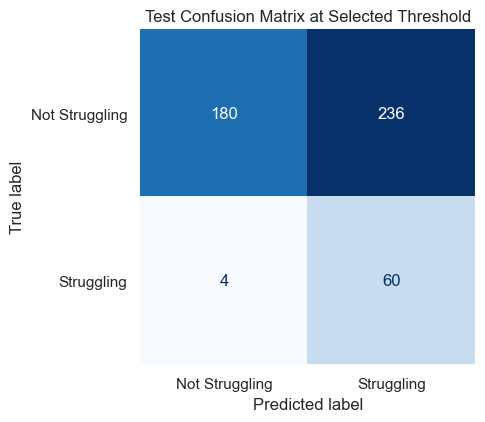

In [15]:
best_model_name = val_results.iloc[0]["model"]
best_pipe = fitted[best_model_name]

val_proba_best = best_pipe.predict_proba(X_val)[:, 1]
selected_threshold = choose_threshold(y_val, val_proba_best, min_precision=0.25)

test_proba = best_pipe.predict_proba(X_test)[:, 1]
test_metrics = metrics_at_threshold(y_test, test_proba, threshold=selected_threshold)
test_metrics["model"] = best_model_name

test_summary = pd.DataFrame([test_metrics])[["model", "threshold", "pr_auc", "roc_auc", "precision", "recall", "f1"]]
display(test_summary)

if pd.Series(y_test).sum() == 0:
    print("Note: Held-out test period has zero positive cases. PR/recall-style metrics are not informative for this slice.")

if len(y_test) < 150 or pd.Series(y_test).sum() < 5:
    print("Reliability note: hold-out sample is small/rare-event. Use rolling backtest summary below as primary reliability readout.")

test_pred = (test_proba >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Struggling", "Struggling"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.title("Test Confusion Matrix at Selected Threshold")
plt.tight_layout()
plt.show()


### How to read the main confusion matrix

This matrix shows how often the model correctly flags struggling residents versus misses them.

- Top-left and bottom-right are correct predictions.
- Bottom-left are missed struggling cases (false negatives).
- Top-right are extra alerts that did not become struggling cases (false positives).

For resident safety, we usually accept some extra alerts to reduce missed cases.

In [16]:
# Reliability check: rolling one-month-ahead backtest on the best model
rolling_months = sorted(model_df["month_m"].unique())
min_train_months = 18
rolling_rows = []

for i in range(min_train_months, len(rolling_months) - 1):
    train_m = rolling_months[:i]
    test_m = [rolling_months[i]]

    fold_train = model_df[model_df["month_m"].isin(train_m)].copy()
    fold_test = model_df[model_df["month_m"].isin(test_m)].copy()

    if fold_train[target_col].nunique() < 2 or len(fold_test) == 0:
        continue

    X_tr = fold_train.drop(columns=drop_cols)
    y_tr = fold_train[target_col]
    X_te = fold_test.drop(columns=drop_cols)
    y_te = fold_test[target_col]

    fold_pipe = Pipeline(steps=[("prep", preprocess), ("model", models[best_model_name])])
    fold_pipe.fit(X_tr, y_tr)
    fold_proba = fold_pipe.predict_proba(X_te)[:, 1]

    fold_metrics = metrics_at_threshold(y_te, fold_proba, threshold=selected_threshold)
    fold_metrics["test_month"] = pd.Timestamp(test_m[0]).date()
    fold_metrics["positives"] = int(y_te.sum())
    fold_metrics["rows"] = int(len(y_te))
    rolling_rows.append(fold_metrics)

rolling_df = pd.DataFrame(rolling_rows)
if len(rolling_df) > 0:
    display(rolling_df.tail(12))

    rolling_summary = pd.DataFrame([
        {
            "rolling_folds": int(len(rolling_df)),
            "mean_pr_auc": float(rolling_df["pr_auc"].mean()),
            "median_pr_auc": float(rolling_df["pr_auc"].median()),
            "mean_precision": float(rolling_df["precision"].mean()),
            "mean_recall": float(rolling_df["recall"].mean()),
            "mean_f1": float(rolling_df["f1"].mean()),
        }
    ])
    display(rolling_summary)
else:
    print("Rolling backtest skipped: insufficient fold coverage with class variation.")


,threshold,pr_auc,roc_auc,precision,recall,f1,test_month,positives,rows
8,0.48503,0.392499,0.597222,0.241379,0.583333,0.341463,2025-03-01,12,60
9,0.48503,0.400423,0.661932,0.384615,0.937500,0.545455,2025-04-01,16,60
10,0.48503,0.741303,0.852431,0.300000,1.000000,0.461538,2025-05-01,12,60
11,0.48503,0.502526,0.718944,0.314286,0.785714,0.448980,2025-06-01,14,60
12,0.48503,0.422820,0.554348,0.272727,0.642857,0.382979,2025-07-01,14,60
13,0.48503,0.440430,0.716346,0.187500,0.750000,0.300000,2025-08-01,8,60
14,0.48503,0.579733,0.854031,0.258065,0.888889,0.400000,2025-09-01,9,60
15,0.48503,0.735711,0.884444,0.428571,1.000000,0.600000,2025-10-01,15,60
16,0.48503,0.454202,0.742115,0.266667,0.727273,0.390244,2025-11-01,11,60
17,0.48503,0.475610,0.778976,0.200000,0.857143,0.324324,2025-12-01,7,60


,rolling_folds,mean_pr_auc,median_pr_auc,mean_precision,mean_recall,mean_f1
0,20,0.519181,0.517982,0.291555,0.82479,0.423017


### How to read the rolling backtest table

Use this table as the reliability check. It summarizes many future-month tests, not just one holdout month.

If one month looks unusually good or bad, the rolling summary helps you avoid overreacting to that single month.

### Sensitivity check: High-only outcome

The main model is built for stronger month-to-month signal (struggling-risk). This check asks a stricter question: how does the same model perform if we only count high-severity incidents as positives?

This helps leadership compare day-to-day triage value versus strict severe-incident targeting.

,scenario,threshold,pr_auc,roc_auc,precision,recall,f1,positives,rows
0,Sensitivity (High-only),0.48503,0.023312,0.671579,0.016892,1.0,0.033223,5,480


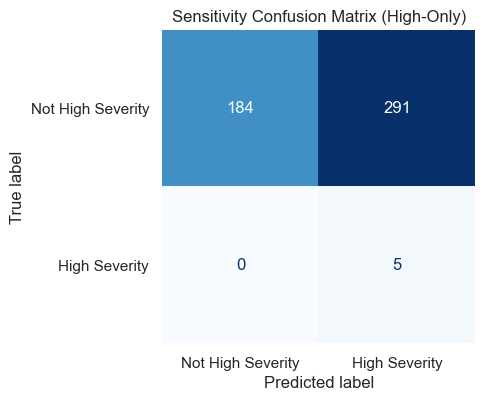

In [17]:
# Sensitivity evaluation: high-severity-only target on the same held-out test months
y_test_high = test_df[sensitivity_col].astype(int)

test_high_metrics = metrics_at_threshold(y_test_high, test_proba, threshold=selected_threshold)
test_high_summary = pd.DataFrame([
    {
        "scenario": "Sensitivity (High-only)",
        "threshold": selected_threshold,
        "pr_auc": test_high_metrics["pr_auc"],
        "roc_auc": test_high_metrics["roc_auc"],
        "precision": test_high_metrics["precision"],
        "recall": test_high_metrics["recall"],
        "f1": test_high_metrics["f1"],
        "positives": int(y_test_high.sum()),
        "rows": int(len(y_test_high)),
    }
])
display(test_high_summary)

test_pred_high = (test_proba >= selected_threshold).astype(int)
cm_high = confusion_matrix(y_test_high, test_pred_high, labels=[0, 1])

disp_high = ConfusionMatrixDisplay(
    confusion_matrix=cm_high,
    display_labels=["Not High Severity", "High Severity"],
)
fig, ax = plt.subplots(figsize=(5, 5))
disp_high.plot(cmap="Blues", ax=ax, colorbar=False)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.title("Sensitivity Confusion Matrix (High-Only)")
plt.tight_layout()
plt.show()


### How to read the high-only sensitivity confusion matrix

This strict matrix checks severe incidents only.

Interpretation tip: because severe events are rare, precision can stay low even when recall improves. That is normal for rare-event screening.

### Additional score-separation visuals

The next two charts help explain threshold behavior and why precision/recall move in opposite directions as threshold changes.

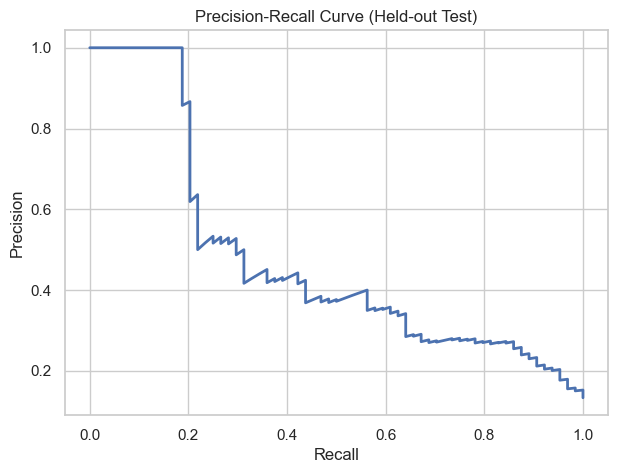

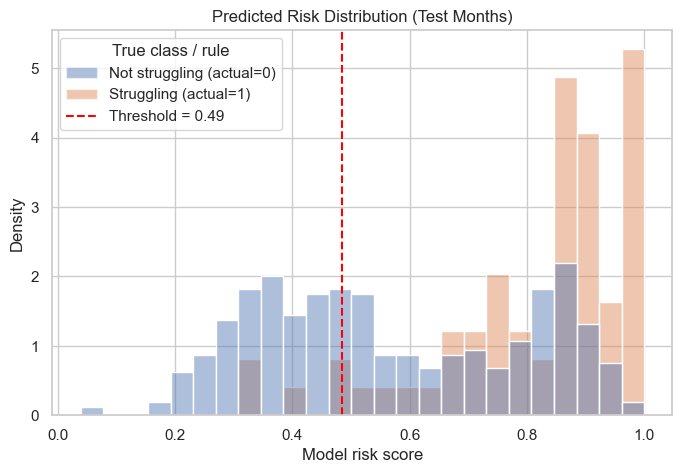

In [18]:
# Chart 1: Precision-Recall curve (test)
if pd.Series(y_test).sum() > 0:
    p_t, r_t, _ = precision_recall_curve(y_test, test_proba)
    plt.figure(figsize=(7, 5))
    plt.plot(r_t, p_t, linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve (Held-out Test)")
    plt.show()
else:
    print("Skipping PR curve: no positive class in held-out test period.")

# Chart 2: Risk score distribution by actual class
from matplotlib.patches import Patch

plot_df = pd.DataFrame({"risk_score": test_proba, "actual": y_test.values})
fig, ax = plt.subplots(figsize=(8, 5))

if HAS_SEABORN:
    # Draw histograms with fixed class colors and then force a manual legend.
    class_palette = {
        0: "#4C72B0",  # blue
        1: "#DD8452",  # orange
    }
    sns.histplot(
        data=plot_df,
        x="risk_score",
        hue="actual",
        bins=25,
        stat="density",
        common_norm=False,
        alpha=0.45,
        hue_order=[0, 1],
        palette=class_palette,
        ax=ax,
        legend=False,
    )

    legend_handles = [
        Patch(facecolor=class_palette[0], alpha=0.45, label="Not struggling (actual=0)"),
        Patch(facecolor=class_palette[1], alpha=0.45, label="Struggling (actual=1)"),
    ]
else:
    class_colors = {
        0: "#4C72B0",
        1: "#DD8452",
    }
    legend_handles = []
    for cls, label in [(0, "Not struggling (actual=0)"), (1, "Struggling (actual=1)")]:
        vals = plot_df.loc[plot_df["actual"] == cls, "risk_score"]
        if len(vals) > 0:
            ax.hist(vals, bins=25, alpha=0.45, density=True, color=class_colors[cls])
        legend_handles.append(Patch(facecolor=class_colors[cls], alpha=0.45, label=label))

ax.axvline(selected_threshold, color="red", linestyle="--", label=f"Threshold = {selected_threshold:.2f}")
ax.set_title("Predicted Risk Distribution (Test Months)")
ax.set_xlabel("Model risk score")
ax.set_ylabel("Density")

# Always show class legend entries, plus threshold line.
threshold_handle = [ax.lines[-1]]
ax.legend(handles=legend_handles + threshold_handle, title="True class / rule")
plt.show()


### How to read the P-R curve and risk-score distribution

Think of these charts as a **threshold decision tool**.

- **Precision-Recall curve** answers: "If we change the threshold, how does alert quality change?"
  - Higher recall = we catch more truly struggling residents.
  - Lower precision = we also send more extra alerts.
  - Choose a point that your team can realistically review each month.

- **Predicted risk distribution** answers: "Do struggling residents actually receive higher scores?"
  - Blue bars = true non-struggling residents.
  - Orange bars = true struggling residents.
  - Red line = current threshold (right side is flagged).

How to interpret quickly:
- If orange is mostly right of blue, the score separates risk well.
- If orange and blue heavily overlap, the model is less decisive and triage will include more extra alerts.

Plain-language takeaway: use both charts together to set a threshold that protects resident safety while keeping workload manageable.

### Threshold and staffing guidance

- Start with the selected threshold as the default monthly alert rule.
- If team capacity is limited, work the highest scores first (top-N list).
- In resident safety work, false negatives are usually more costly than false positives.
- False positives create extra workload; false negatives can miss residents who need early intervention.
- Revisit threshold quarterly (or sooner) if workload or outcomes shift.

### Top-K triage performance (monthly)

This section answers a staffing reality question in plain terms: if the team can review only the top `K` residents each month, how many true high-severity cases are likely to be found?

In [19]:
# Monthly Precision@K / Recall@K for strict high-only sensitivity target
K_values = [5, 10, 15]
rank_df = test_df[["resident_id", "month_m", sensitivity_col]].copy()
rank_df["score_struggling_model"] = test_proba
rank_df = rank_df.rename(columns={sensitivity_col: "y_high"})

rows = []
for month, g in rank_df.groupby("month_m"):
    g = g.sort_values("score_struggling_model", ascending=False).reset_index(drop=True)
    positives_month = int(g["y_high"].sum())
    for K in K_values:
        top = g.head(min(K, len(g)))
        tp = int(top["y_high"].sum())
        precision_at_k = tp / len(top) if len(top) > 0 else np.nan
        recall_at_k = tp / positives_month if positives_month > 0 else np.nan
        rows.append(
            {
                "month": pd.Timestamp(month).date(),
                "K": K,
                "positives_in_month": positives_month,
                "tp_in_top_k": tp,
                "precision_at_k": precision_at_k,
                "recall_at_k": recall_at_k,
            }
        )

p_at_k_monthly = pd.DataFrame(rows)
display(p_at_k_monthly.tail(12))

p_at_k_summary = (
    p_at_k_monthly.groupby("K", as_index=False)
    .agg(
        months=("month", "count"),
        avg_precision_at_k=("precision_at_k", "mean"),
        avg_recall_at_k=("recall_at_k", "mean"),
        median_precision_at_k=("precision_at_k", "median"),
        median_recall_at_k=("recall_at_k", "median"),
    )
)
display(p_at_k_summary)


,month,K,positives_in_month,tp_in_top_k,precision_at_k,recall_at_k
12,2025-12-01,5,0,0,0.000000,NaN
13,2025-12-01,10,0,0,0.000000,NaN
14,2025-12-01,15,0,0,0.000000,NaN
15,2026-01-01,5,1,0,0.000000,0.0
16,2026-01-01,10,1,1,0.100000,1.0
17,2026-01-01,15,1,1,0.066667,1.0
18,2026-02-01,5,0,0,0.000000,NaN
19,2026-02-01,10,0,0,0.000000,NaN
20,2026-02-01,15,0,0,0.000000,NaN
21,2026-03-01,5,0,0,0.000000,NaN


,K,months,avg_precision_at_k,avg_recall_at_k,median_precision_at_k,median_recall_at_k
0,5,8,0.000000,0.000,0.0,0.00
1,10,8,0.025000,0.375,0.0,0.25
2,15,8,0.016667,0.375,0.0,0.25


### How to read Top-K tables

- `precision_at_k`: of the top `K` residents flagged, how many were true severe cases.
- `recall_at_k`: of all severe cases that month, how many were captured in top `K`.
- Use this for staffing decisions (example: if team can review 10 cases/month, use the `K=10` row).

### Two-stage severe-risk workflow

Stage 1 screens for likely struggling residents.

Stage 2 then focuses only on that smaller group and predicts strict high-severity risk. This usually improves severe-case precision because the model is no longer searching the full resident list.

In [20]:
# Two-stage model: train strict high-only model within Stage-1 screened residents
# Stage-1 screening threshold chosen on validation via struggling model probabilities.
stage1_val_pool = val_df.copy()
stage1_val_pool["score_stage1"] = val_proba_best

# Grid keeps enough residents for review and seeks better high-only precision.
pool_grid = np.linspace(np.percentile(stage1_val_pool["score_stage1"], 60), np.percentile(stage1_val_pool["score_stage1"], 95), 8)
best_pool_thr = float(np.median(pool_grid))
best_pool_prec = -1

for thr in pool_grid:
    pool = stage1_val_pool[stage1_val_pool["score_stage1"] >= thr].copy()
    if len(pool) < 10:
        continue
    prec = pool[sensitivity_col].mean()
    if prec > best_pool_prec:
        best_pool_prec = prec
        best_pool_thr = float(thr)

# Build high-only training data from screened train residents
stage1_train = train_df.copy()
stage1_train["score_stage1"] = best_pipe.predict_proba(X_train)[:, 1]
train_pool = stage1_train[stage1_train["score_stage1"] >= best_pool_thr].copy()

if train_pool[sensitivity_col].nunique() < 2 or len(train_pool) < 20:
    print("Two-stage training pool too small or single-class; skipping second-stage fit.")
else:
    X_train_pool = train_pool.drop(columns=drop_cols)
    y_train_pool_high = train_pool[sensitivity_col].astype(int)

    stage2_model = Pipeline(
        steps=[("prep", preprocess), ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))]
    )
    stage2_model.fit(X_train_pool, y_train_pool_high)

    # Apply workflow on held-out test set
    stage1_test = test_df.copy()
    stage1_test["score_stage1"] = test_proba
    test_pool = stage1_test[stage1_test["score_stage1"] >= best_pool_thr].copy()

    if len(test_pool) == 0:
        print("No test residents passed Stage-1 threshold.")
    else:
        X_test_pool = test_pool.drop(columns=drop_cols)
        y_test_pool_high = test_pool[sensitivity_col].astype(int)
        stage2_proba = stage2_model.predict_proba(X_test_pool)[:, 1]
        stage2_thr = choose_threshold(y_test_pool_high, stage2_proba, min_precision=0.10)
        stage2_metrics = metrics_at_threshold(y_test_pool_high, stage2_proba, stage2_thr)

        two_stage_summary = pd.DataFrame(
            [
                {
                    "workflow": "Two-stage high-only (screen + refine)",
                    "stage1_pool_threshold": best_pool_thr,
                    "test_pool_size": int(len(test_pool)),
                    "test_pool_positive_rate": float(y_test_pool_high.mean()),
                    "stage2_threshold": stage2_thr,
                    "pr_auc": stage2_metrics["pr_auc"],
                    "roc_auc": stage2_metrics["roc_auc"],
                    "precision": stage2_metrics["precision"],
                    "recall": stage2_metrics["recall"],
                    "f1": stage2_metrics["f1"],
                }
            ]
        )
        display(two_stage_summary)


,workflow,stage1_pool_threshold,test_pool_size,test_pool_positive_rate,stage2_threshold,pr_auc,roc_auc,precision,recall,f1
0,Two-stage high-only (screen + refine),0.920341,33,0.030303,0.014407,0.142857,0.8125,0.142857,1.0,0.25


### How to read the two-stage table

- `stage1_pool_threshold`: only residents above this first-stage score move to stage 2.
- `test_pool_size`: how many residents the severe-risk model actually evaluates.
- `test_pool_positive_rate`: severe-case prevalence inside that pool (usually higher than full test set).
- Goal: improve severe-case precision while keeping useful recall for safety follow-up.

In [21]:
# Lightweight subgroup check (coverage by safehouse / risk group)
def subgroup_metrics(df, y_true_col, score_col, threshold, group_col):
    rows = []
    for g, part in df.groupby(group_col):
        y = part[y_true_col].astype(int)
        if len(y) < 20:
            continue
        pred = (part[score_col] >= threshold).astype(int)
        tp = int(((pred == 1) & (y == 1)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        fn = int(((pred == 0) & (y == 1)).sum())
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        rows.append(
            {
                "group": g,
                "rows": int(len(part)),
                "positives": int(y.sum()),
                "precision": precision,
                "recall": recall,
            }
        )
    return pd.DataFrame(rows)

test_eval = test_df.copy()
test_eval["score_main"] = test_proba

safehouse_check = subgroup_metrics(
    df=test_eval,
    y_true_col=target_col,
    score_col="score_main",
    threshold=selected_threshold,
    group_col="safehouse_id",
)
if len(safehouse_check) > 0:
    display(safehouse_check.sort_values("recall", ascending=False))
else:
    print("Subgroup check skipped: not enough rows per safehouse.")


,group,rows,positives,precision,recall
0,1,80,16,0.266667,1.000000
2,3,56,5,0.208333,1.000000
3,4,64,6,0.187500,1.000000
7,8,48,6,0.206897,1.000000
6,7,64,13,0.317073,1.000000
1,2,64,7,0.153846,0.857143
4,5,48,5,0.133333,0.800000
5,6,40,5,0.090909,0.600000


## 5. Causal and Relationship Analysis

This section explains relationships in the data. It does not prove causation.

We use an interpretable logistic model to show which factors are associated with higher or lower struggling risk next month.

In [22]:
# Explanatory model: logistic regression on train+val, evaluated on test
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

explain_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced")),
])
explain_pipe.fit(X_trainval, y_trainval)
explain_proba_test = explain_pipe.predict_proba(X_test)[:, 1]
explain_metrics = metrics_at_threshold(y_test, explain_proba_test, threshold=0.5)
display(pd.DataFrame([explain_metrics]))

feat_names = explain_pipe.named_steps["prep"].get_feature_names_out()
coefs = explain_pipe.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feat_names,
    "coefficient": coefs,
    "odds_ratio": np.exp(coefs),
})

top_positive = coef_df.sort_values("coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("coefficient", ascending=True).head(10)

display(top_positive)
display(top_negative)


,threshold,pr_auc,roc_auc,precision,recall,f1
0,0.5,0.50757,0.821026,0.236052,0.859375,0.37037


,feature,coefficient,odds_ratio
28,num__intervention_updated_m,0.801297,2.228429
33,num__incident_any_m,0.746142,2.108849
62,cat__referral_source_NGO,0.562882,1.755726
4,num__energy_score_m,0.445660,1.561520
29,num__intervention_touches_m,0.425498,1.530352
1,num__month_index,0.365525,1.441270
53,cat__initial_risk_level_Low,0.325265,1.384397
12,num__avg_session_duration_m,0.282638,1.326625
50,cat__case_category_Surrendered,0.268333,1.307782
56,cat__current_risk_level_High,0.240878,1.272366


,feature,coefficient,odds_ratio
30,num__incident_count_m,-0.802027,0.448419
63,cat__referral_source_Police,-0.430246,0.650349
64,cat__referral_source_Self-Referral,-0.402973,0.668330
55,cat__current_risk_level_Critical,-0.289243,0.748830
47,cat__case_category_Abandoned,-0.269288,0.763923
60,cat__referral_source_Court Order,-0.256088,0.774073
49,cat__case_category_Neglected,-0.242137,0.784948
44,cat__med_checkup_m_True,-0.228870,0.795432
6,num__bmi_m,-0.198331,0.820098
54,cat__initial_risk_level_Medium,-0.197029,0.821166


### Relationship interpretation notes

- Positive coefficients: linked with higher next-month struggling risk (all else held constant in the model).
- Negative coefficients: linked with lower next-month struggling risk.
- This is observational data, so these are associations, not proven cause-and-effect findings.
- Use these signals to guide case-review priorities and better data collection, not to make deterministic claims.

## 6. Deployment Notes

### Executive recommendation

Use the model as a **monthly triage assistant**.

If staffing allows about **10 case reviews per month**, start with this sequence:
1. Review the monthly **Top-10 risk scores** first.
2. Expand to additional threshold-based alerts only if capacity remains.

This operating rule prioritizes safety coverage while keeping workload predictable.

### Limitations and monitoring

- Use this tool to support human case review decisions, not replace them.
- High-severity incidents are rare, so high-only precision will usually be lower.
- Program changes and intake shifts can move model performance over time.
- **Primary safety KPIs:** `miss_rate`, `review_within_7_days`.
- **Secondary workload KPIs:** `hit_rate`, `alert_volume`, queue size.
- Recalibrate thresholds quarterly (or sooner when outcomes or capacity shift).

### Synthesis for decision-makers

- **Shared signal:** both approaches highlight recent incident burden and intervention intensity as important warning signs.
- **Best use of prediction:** rank residents for immediate monthly triage decisions.
- **Best use of explanation:** communicate associated risk patterns and improve program design over time.
- **Causality boundary:** results show association, not proof of cause-and-effect.

### Deployment workflow

Recommended monthly workflow:
1. Build resident-month features after month close.
2. Score all active residents.
3. Apply threshold and risk tiers.
4. Send ranked triage list to case managers.
5. Track monthly outcomes (precision, recall, queue size) and review threshold quarterly.

Simple integration pattern:
- save model + feature schema,
- run as a scheduled scoring job or API endpoint,
- log predictions and outcomes to monitor drift and real-world performance.

### Playbook KPI glossary

- `risk_score`: model score for next-month struggling risk.
- `alert_volume`: number of residents flagged this month.
- `hit_rate`: flagged residents who later show the target event.
- `miss_rate`: target events that were not flagged.
- `review_within_7_days`: share of flagged residents reviewed within 7 days.

**Primary KPIs (safety):** `miss_rate`, `review_within_7_days`.

**Secondary KPIs (efficiency/workload):** `hit_rate`, `alert_volume`.

In [23]:
action_playbook = pd.DataFrame([
    {
        "Tier": "High risk",
        "Rule": f"risk_score >= {selected_threshold:.2f}",
        "Action": "Immediate case conference, social-worker follow-up within 7 days, and intervention plan update.",
        "Owner": "Case manager + supervisor",
        "Primary KPI": "miss_rate",
    },
    {
        "Tier": "Watch list",
        "Rule": f"{max(0.10, selected_threshold - 0.15):.2f} <= risk_score < {selected_threshold:.2f}",
        "Action": "Increase touchpoints this month and schedule focused counseling check-in.",
        "Owner": "Assigned social worker",
        "Primary KPI": "review_within_7_days",
    },
    {
        "Tier": "Routine",
        "Rule": f"risk_score < {max(0.10, selected_threshold - 0.15):.2f}",
        "Action": "Continue standard monitoring and reassess in monthly scoring cycle.",
        "Owner": "Case worker",
        "Primary KPI": "alert_volume",
    },
])

display(action_playbook)

operating_rule = pd.DataFrame([
    {
        "Monthly operating rule": "If staffing cannot cover all alerts, prioritize highest risk_score first (top-N queue).",
        "Threshold governance": "Recalibrate threshold quarterly or when hit_rate shifts materially.",
        "Primary metric family": "PR-AUC, recall, precision, F1, ROC-AUC",
    }
])

print("OPERATING RULE DETAILS")
print(operating_rule.to_string(index=False))


,Tier,Rule,Action,Owner,Primary KPI
0,High risk,risk_score >= 0.49,"Immediate case conference, social-worker follo...",Case manager + supervisor,miss_rate
1,Watch list,0.34 <= risk_score < 0.49,Increase touchpoints this month and schedule f...,Assigned social worker,review_within_7_days
2,Routine,risk_score < 0.34,Continue standard monitoring and reassess in m...,Case worker,alert_volume


OPERATING RULE DETAILS
                                                                 Monthly operating rule                                                Threshold governance                  Primary metric family
If staffing cannot cover all alerts, prioritize highest risk_score first (top-N queue). Recalibrate threshold quarterly or when hit_rate shifts materially. PR-AUC, recall, precision, F1, ROC-AUC
